# Part I - Socioeconomic Inequality in Education across the Arab World
## by Malak Battatt

## Introduction

In this notebook, I explore the **PISA 2022 Student Questionnaire** dataset, focusing on six Arab countries that participated in the assessment: **Palestine, Jordan, Morocco, Qatar, Saudi Arabia, and UAE**. PISA (Programme for International Student Assessment) is an OECD survey that tests 15-year-old students in mathematics, reading, and science every three years.

The main theme I'm looking into is **socioeconomic inequality in education** — specifically, whether a student's family background affects how well they do in math. The questions I want to answer are:

1. How are math scores distributed across Arab countries?
2. Is there a gender gap in math scores, and does it vary by country?
3. Does socioeconomic status affect boys and girls differently across countries?
4. Which countries show the largest inequality gap between rich and poor students?

## Preliminary Wrangling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load the cleaned dataset (pre-filtered to Arab countries, averaged plausible values)
df = pd.read_csv('../data/pisa_arab_clean.csv')

# High-level overview
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: (61775, 12)

Data types:
CNT                     str
gender                  str
immigrant_status    float64
belonging           float64
math_anxiety        float64
parent_edu          float64
parent_occ          float64
ict_resources       float64
ses                 float64
math_score          float64
ses_quartile            str
country                 str
dtype: object

First 5 rows:


,CNT,gender,immigrant_status,belonging,math_anxiety,parent_edu,parent_occ,ict_resources,ses,math_score,ses_quartile,country
0,PSE,Male,1.0,-0.0437,NaN,10.0,NaN,0.7702,-0.6594,425.1980,Q2,Palestine
1,PSE,Male,1.0,0.3142,0.4067,6.0,75.43,-1.3579,-0.7512,338.6617,Q2,Palestine
2,PSE,Male,1.0,-1.1019,0.9050,10.0,16.50,-0.9708,-0.7349,247.1388,Q2,Palestine
3,PSE,Male,1.0,-0.6206,NaN,10.0,76.65,1.5386,1.6743,279.3831,Q4 (Highest),Palestine
4,PSE,Male,1.0,1.0491,0.4290,5.0,23.57,-1.3160,-1.7778,400.1433,Q1 (Lowest),Palestine


In [3]:
# Check missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})

,missing_count,missing_%
CNT,0,0.00
gender,0,0.00
immigrant_status,5981,9.68
belonging,5714,9.25
math_anxiety,14123,22.86
parent_edu,2659,4.30
parent_occ,9017,14.60
ict_resources,2018,3.27
ses,2432,3.94
math_score,0,0.00


In [4]:
# Ordered SES quartile for proper plot ordering
ses_order = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
df['ses_quartile'] = pd.Categorical(df['ses_quartile'], categories=ses_order, ordered=True)

# Country order by mean math score (used across plots)
country_order = df.groupby('country')['math_score'].mean().sort_values().index.tolist()

print('Countries in dataset (sorted by mean math score):')
print(country_order)
print('\nStudents per country:')
print(df['country'].value_counts())

Countries in dataset (sorted by mean math score):
['Jordan', 'Morocco', 'Palestine', 'Saudi Arabia', 'Qatar', 'UAE']

Students per country:
country
UAE             24600
Palestine        7905
Jordan           7799
Qatar            7676
Saudi Arabia     6928
Morocco          6867
Name: count, dtype: int64


### What is the structure of your dataset?

The cleaned dataset has **61,775 students** from 6 Arab countries. It has 12 variables. The main variable I'm looking at is `math_score`, which I calculated by averaging the 10 plausible values PISA provides for each student — this is the standard way to handle PISA scores. Other variables include `ses` (the socioeconomic status index), `gender`, `country`, `ses_quartile`, and a few psychological measures like `math_anxiety` and `belonging`.

### What is/are the main feature(s) of interest in your dataset?

My main outcome variable is `math_score`. The main variable I want to use to explain it is `ses` (socioeconomic status), with `gender` and `country` as grouping variables.

### What features in the dataset do you think will help support your investigation?

Along with SES and gender, I think `math_anxiety`, `belonging`, and `ict_resources` could be interesting to look at. `parent_edu` and `parent_occ` give more detail about the family's socioeconomic background.

---
## Univariate Exploration

Before looking at any relationships, I want to first get a feel for each variable on its own — what the distributions look like, whether there are any outliers or unusual patterns, and whether anything needs to be transformed or cleaned up. Some of what I find here might connect to my research questions, and some might just be useful context.

> **Question 1**: What does the overall distribution of math scores look like? Is it roughly normal, skewed, or something else?

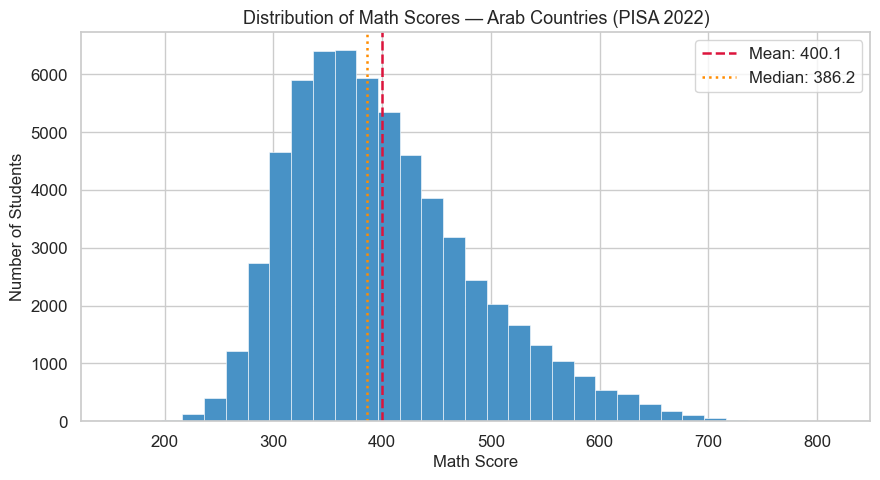

In [5]:
# Plot 1: Histogram of math scores (overall)
fig, ax = plt.subplots(figsize=(9, 5))

binsize = 20
bins = np.arange(df['math_score'].min(), df['math_score'].max() + binsize, binsize)

ax.hist(df['math_score'], bins=bins, color=sb.color_palette('Blues_d')[2], edgecolor='white', linewidth=0.4)

# Annotate mean and median
mean_score = df['math_score'].mean()
median_score = df['math_score'].median()
ax.axvline(mean_score, color='crimson', linestyle='--', linewidth=1.8, label=f'Mean: {mean_score:.1f}')
ax.axvline(median_score, color='darkorange', linestyle=':', linewidth=1.8, label=f'Median: {median_score:.1f}')

ax.set_xlabel('Math Score', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Distribution of Math Scores — Arab Countries (PISA 2022)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** The distribution is right-skewed. The mean (400.1) is higher than the median (386.2) by about 14 points, which is consistent with a right-skewed distribution where higher scores pull the mean up. Most students score somewhere between 300 and 500.

> **Question 2**: What does the distribution of the SES index look like? Is it centered around the OECD average?

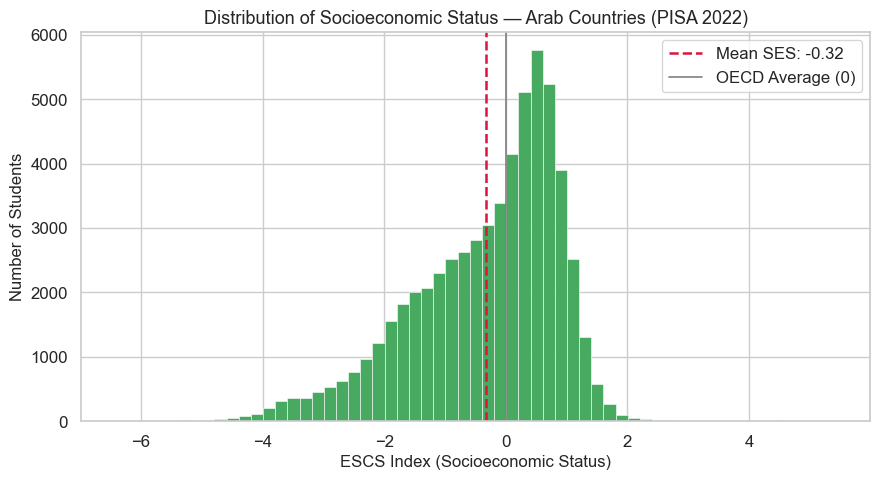

In [6]:
# Plot 2: Histogram of SES index
fig, ax = plt.subplots(figsize=(9, 5))

binsize = 0.2
bins = np.arange(df['ses'].min(), df['ses'].max() + binsize, binsize)

ax.hist(df['ses'].dropna(), bins=bins, color=sb.color_palette('Greens_d')[2], edgecolor='white', linewidth=0.4)

ax.axvline(df['ses'].mean(), color='crimson', linestyle='--', linewidth=1.8,
           label=f"Mean SES: {df['ses'].mean():.2f}")
ax.axvline(0, color='grey', linestyle='-', linewidth=1.2, label='OECD Average (0)')

ax.set_xlabel('ESCS Index (Socioeconomic Status)', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Distribution of Socioeconomic Status — Arab Countries (PISA 2022)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** The SES distribution is left-skewed, with a peak around 0 to +0.5 and a long tail extending to the left down to about -5. The mean SES is -0.32, which sits to the left of the OECD average of 0, meaning the majority of students in this sample are below the OECD average socioeconomically. The left tail is quite long, indicating there are a notable number of students from very low SES backgrounds in the sample.

### Discuss the distribution(s) of your variable(s) of interest.

Math scores across Arab countries are right-skewed with a mean of around 400, which is well below the OECD average of 472. The distribution looks quite different country by country: Jordan, Morocco, Palestine, and Saudi Arabia all have narrow, tightly packed distributions centered around 320–360, while Qatar and UAE are much wider with longer right tails, meaning there's a lot more variation in student performance in those two countries. I didn't apply any transformation to the math scores — the skew is mild enough that it doesn't affect the visualizations.

### Were there any unusual distributions?

The SES distribution was left-skewed with the peak sitting around 0 to +0.5 and a long tail stretching to the left. The mean SES of -0.32 is below the OECD average, meaning most students in this sample come from below-average socioeconomic backgrounds. No transformations were needed, but I created the `ses_quartile` variable as an ordered categorical column to make it easier to compare low vs high SES groups later.

---
## Bivariate Exploration

Now that I have a sense of the individual variables, I want to start looking at how they relate to each other. Not all of these will directly answer my research questions — some are just worth checking to understand the structure of the data better.

> **Question 3**: How does the math score distribution look for each country separately? Do they all follow a similar shape?

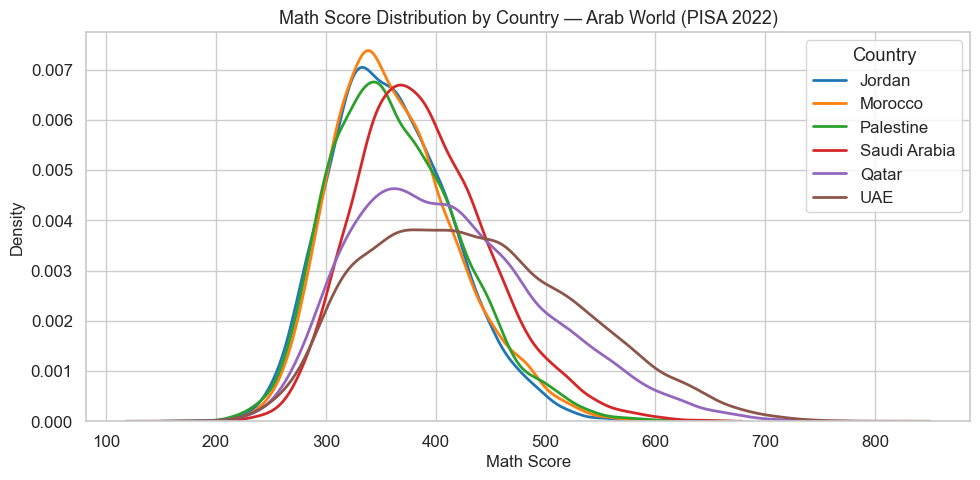

In [7]:
# Plot 3: Overlapping KDE distributions of math scores by country
fig, ax = plt.subplots(figsize=(10, 5))

palette = sb.color_palette('tab10', n_colors=6)

for i, country in enumerate(country_order):
    subset = df[df['country'] == country]['math_score']
    sb.kdeplot(subset, ax=ax, label=country, color=palette[i], linewidth=2)

ax.set_xlabel('Math Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Math Score Distribution by Country — Arab World (PISA 2022)', fontsize=13)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

**Observation:** The countries don't all look the same. Jordan, Morocco, Palestine, and Saudi Arabia all have relatively narrow, tall peaks centered roughly between 320 and 360 — their students' scores are fairly tightly packed together. Qatar is noticeably wider and flatter with a longer right tail, and UAE has the broadest distribution of all, with scores spreading well beyond 600. This suggests that Qatar and UAE have much more variation in student performance than the other four countries.

> **Question 4**: How many students are there per country, and is the gender split balanced?

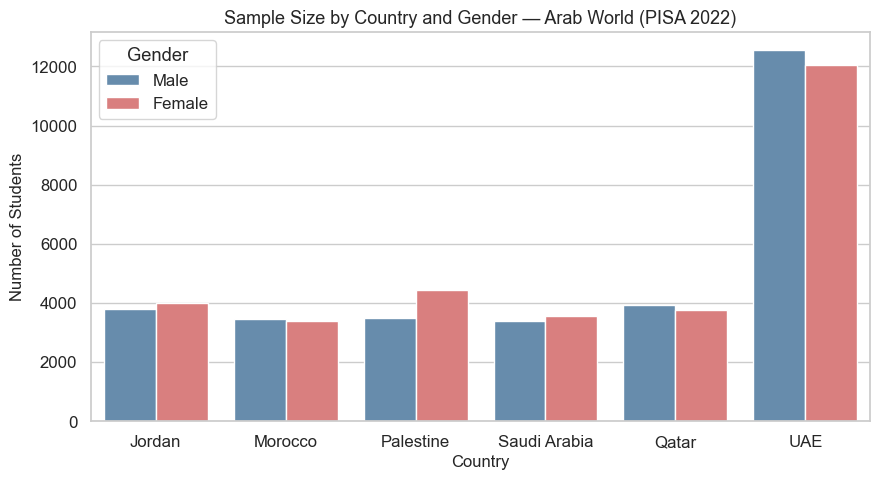

In [8]:
# Plot 4: Count plot — students per country, split by gender
fig, ax = plt.subplots(figsize=(9, 5))

sb.countplot(
    data=df,
    x='country',
    hue='gender',
    order=country_order,
    palette={'Female': '#E87070', 'Male': '#5B8DB8'},
    ax=ax
)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Sample Size by Country and Gender — Arab World (PISA 2022)', fontsize=13)
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

**Observation:** UAE has a much larger sample than the other countries — 24,600 students, roughly three times the size of any other country in the dataset. This means regional averages will be heavily influenced by UAE. The gender is well-balanced within each country, with roughly equal numbers of male and female students.

> **Question 5**: Is there a relationship between SES and math score? Does a higher SES go with a higher score?

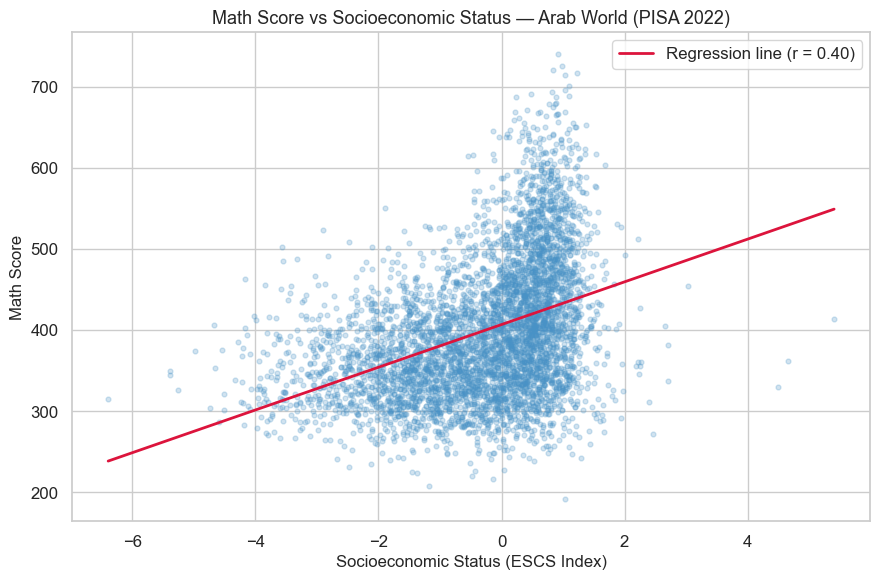

In [9]:
# Plot 5: Scatter plot — SES vs math score (sampled for clarity)
sample = df.dropna(subset=['ses']).sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    sample['ses'], sample['math_score'],
    alpha=0.25, s=12, color=sb.color_palette('Blues_d')[2]
)

# Add regression line
m, b = np.polyfit(sample['ses'], sample['math_score'], 1)
x_line = np.linspace(sample['ses'].min(), sample['ses'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label=f'Regression line (r = 0.40)')

ax.set_xlabel('Socioeconomic Status (ESCS Index)', fontsize=12)
ax.set_ylabel('Math Score', fontsize=12)
ax.set_title('Math Score vs Socioeconomic Status — Arab World (PISA 2022)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** There's a positive relationship between SES and math score (r = 0.40), with the regression line showing roughly a 28-point increase in math score for every 1-unit increase in SES. However, the scatter is quite wide — there's a lot of variation in scores at every SES level, meaning SES alone doesn't tell the full story. One thing worth noting is that the spread of scores seems to get wider as SES increases, with higher-SES students showing more variation in their math scores than lower-SES students.

> **Question 6**: Do boys and girls score differently in math? Does this vary by country?

C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\750898690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\750898690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\750898690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\750898690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `le

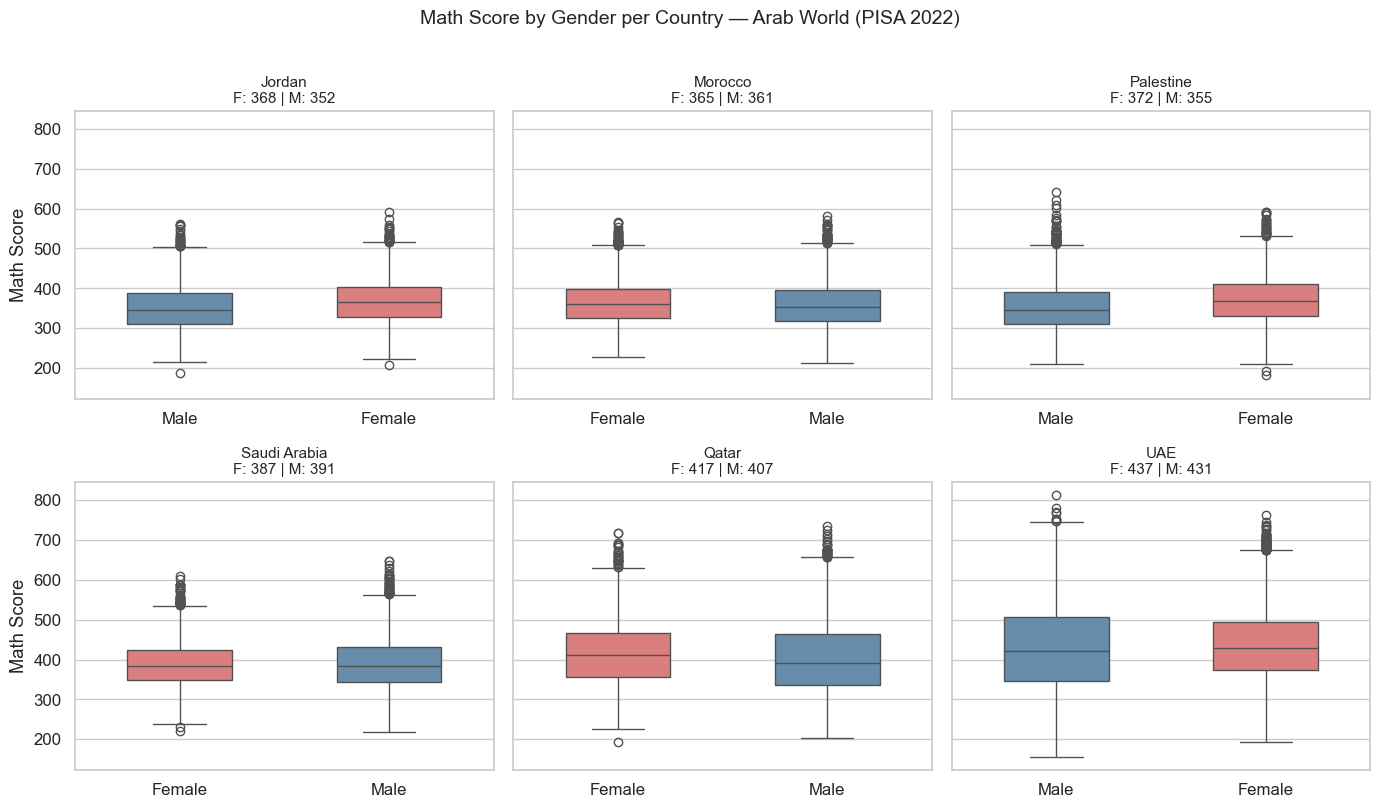

In [10]:
# Plot 6: Box plots — math score by gender, faceted by country
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, country in enumerate(country_order):
    subset = df[df['country'] == country]
    sb.boxplot(
        data=subset, x='gender', y='math_score',
        palette={'Female': '#E87070', 'Male': '#5B8DB8'},
        ax=axes[i], width=0.5
    )
    mean_f = subset[subset['gender'] == 'Female']['math_score'].mean()
    mean_m = subset[subset['gender'] == 'Male']['math_score'].mean()
    axes[i].set_title(f'{country}\nF: {mean_f:.0f} | M: {mean_m:.0f}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Math Score' if i % 3 == 0 else '')

fig.suptitle('Math Score by Gender per Country — Arab World (PISA 2022)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Girls score higher than boys in 5 out of 6 countries. The gap is largest in Palestine (F: 372 vs M: 355, 17 points) and Jordan (F: 368 vs M: 352, 16 points). In Morocco and UAE the difference is very small — just 4 and 6 points respectively. Qatar also shows girls ahead by 10 points (F: 417 vs M: 407). Saudi Arabia is the only country where boys score higher, but only by 4 points (M: 391 vs F: 387). The box sizes are noticeably larger in Qatar and UAE compared to the other four countries, meaning there's more spread in scores in those two countries.

> **Question 7**: Does math score go up consistently as SES quartile increases?

C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\2888474998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


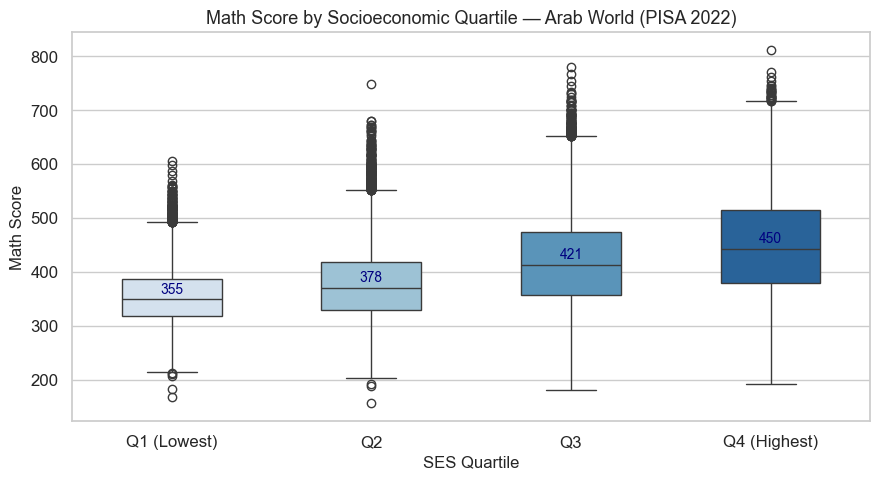

In [11]:
# Plot 7: Box plot — math score by SES quartile
fig, ax = plt.subplots(figsize=(9, 5))

sb.boxplot(
    data=df, x='ses_quartile', y='math_score',
    order=ses_order,
    palette='Blues',
    ax=ax, width=0.5
)

# Annotate means
means = df.groupby('ses_quartile')['math_score'].mean()
for i, q in enumerate(ses_order):
    ax.text(i, means[q] + 5, f'{means[q]:.0f}', ha='center', fontsize=10, color='navy')

ax.set_xlabel('SES Quartile', fontsize=12)
ax.set_ylabel('Math Score', fontsize=12)
ax.set_title('Math Score by Socioeconomic Quartile — Arab World (PISA 2022)', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Math scores go up at every step from Q1 to Q4: Q1=355, Q2=378, Q3=421, Q4=450. The jump from Q2 to Q3 (43 points) is larger than the other steps, which are around 23–29 points each. The boxes also get wider from Q1 to Q4, meaning higher-SES students show more variation in their scores. All four quartiles have outliers on the high end — so there are students from even the lowest SES backgrounds who scored quite high — though these are clearly exceptions rather than the norm.

> **Question 8**: How do math score, SES, math anxiety, and other variables correlate with each other?

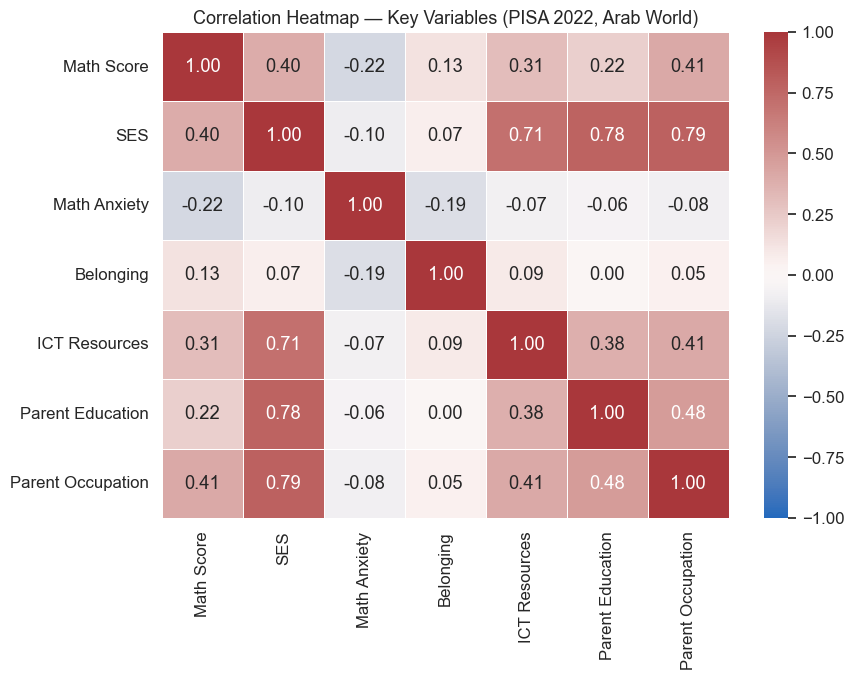

In [12]:
# Plot 8: Heatmap of correlations
numeric_vars = ['math_score', 'ses', 'math_anxiety', 'belonging', 'ict_resources', 'parent_edu', 'parent_occ']
corr_matrix = df[numeric_vars].corr()

# Rename for cleaner labels
labels = {
    'math_score': 'Math Score',
    'ses': 'SES',
    'math_anxiety': 'Math Anxiety',
    'belonging': 'Belonging',
    'ict_resources': 'ICT Resources',
    'parent_edu': 'Parent Education',
    'parent_occ': 'Parent Occupation'
}
corr_matrix = corr_matrix.rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(9, 7))
sb.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='vlag', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation Heatmap — Key Variables (PISA 2022, Arab World)', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Looking at the first row/column, the variables most correlated with math score are Parent Occupation (r = 0.41), SES (r = 0.40), and ICT Resources (r = 0.31). Math Anxiety has a negative correlation with math score (r = -0.22), so students with higher anxiety tend to score lower. Parent Education and Parent Occupation are both very strongly correlated with SES (r = 0.78 and r = 0.79), which makes sense since they are all components of socioeconomic background. ICT Resources also correlates strongly with SES (r = 0.71). Belonging stands out as having very weak correlations with almost every other variable, close to 0 across the board, except for a mild negative correlation with Math Anxiety (r = -0.19).

### Talk about some of the relationships you observed.

The scatter plot showed a positive relationship between SES and math score (r = 0.40), though the wide spread means many other factors are also at play. From the box plots, girls score higher than boys in 5 out of 6 countries, with the largest gaps in Palestine and Jordan. The SES quartile box plot showed a consistent step-up in scores from Q1 to Q4, with the biggest jump happening between Q2 and Q3.

### Did you observe any interesting relationships between other features?

The heatmap showed that Parent Occupation (r = 0.41) and SES (r = 0.40) have almost identical correlations with math score. Parent Education and Parent Occupation are both very strongly correlated with SES (r = 0.78 and 0.79), which makes sense since they all reflect family background. The high correlation between SES and ICT Resources (r = 0.71) also stood out. Belonging had surprisingly weak correlations with almost everything else.

---
## Multivariate Exploration

Here I'll bring three or more variables together at once. Some of these plots came out of things I noticed in the bivariate section that I wanted to dig into further — like whether the SES–score relationship looks the same for boys and girls, or whether it changes across countries.

> **Question 9**: Does SES affect boys and girls the same way across all countries?

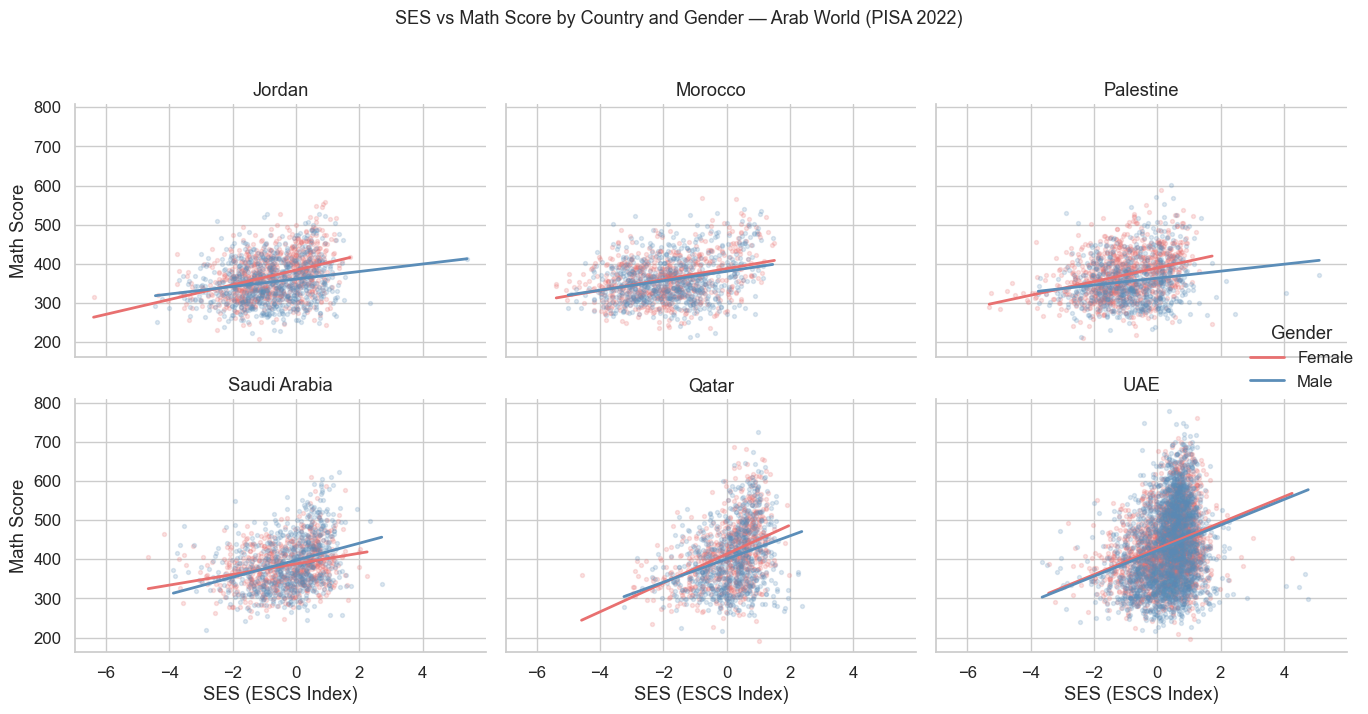

In [13]:
# Plot 9: Facet plot — SES vs math score by country, colored by gender
sample2 = df.dropna(subset=['ses']).sample(n=12000, random_state=42)

g = sb.FacetGrid(
    data=sample2,
    col='country', col_order=country_order,
    col_wrap=3,
    hue='gender',
    palette={'Female': '#E87070', 'Male': '#5B8DB8'},
    height=3.5, aspect=1.2
)

g.map(plt.scatter, 'ses', 'math_score', alpha=0.2, s=8)
g.map(sb.regplot, 'ses', 'math_score',
      scatter=False, ci=None,
      line_kws={'linewidth': 2})

g.add_legend(title='Gender')
g.set_axis_labels('SES (ESCS Index)', 'Math Score')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('SES vs Math Score by Country and Gender — Arab World (PISA 2022)',
                   y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** In all 6 countries, both boys and girls show a positive relationship between SES and math score. In Jordan, Qatar, and Palestine, the female line is noticeably steeper than the male line — meaning girls gain more from higher SES in those countries than boys do. In Morocco and UAE, the two lines are much closer together in both slope and position. Saudi Arabia stands out as the only country where the male line is steeper, meaning boys gain more from higher SES there, and they also score slightly higher overall. Girls score higher than boys in most countries, but the size of that advantage isn't uniform — it varies across countries and SES levels.

> **Question 10**: Which countries have the biggest gap between their richest and poorest students?

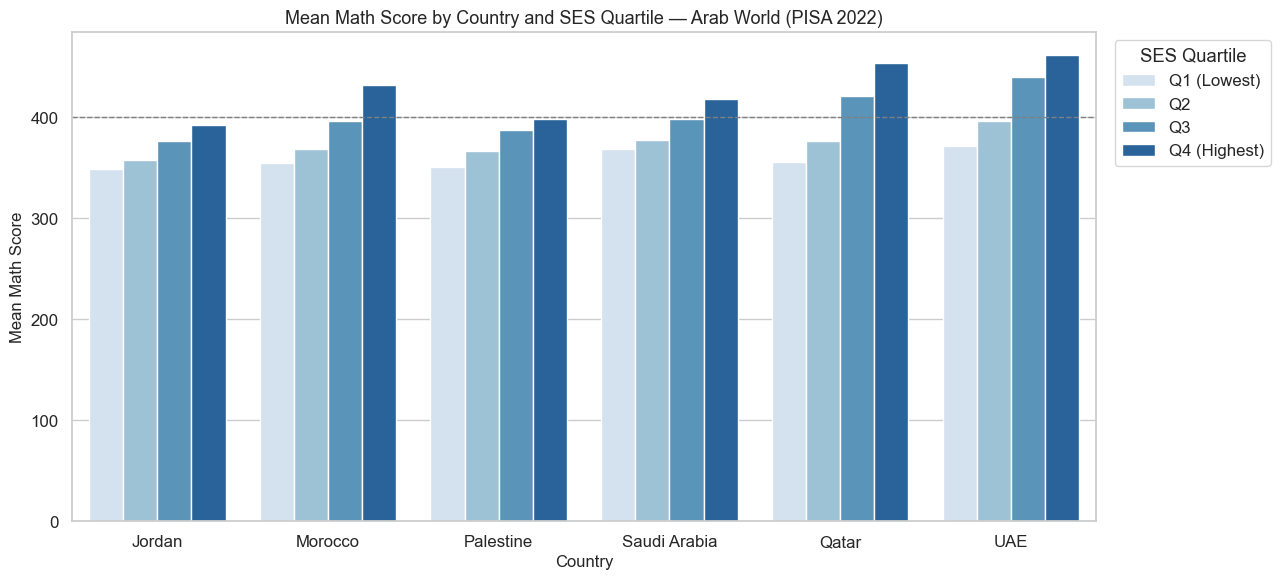

In [14]:
# Plot 10: Clustered bar chart — mean math score by country and SES quartile
grouped = df.groupby(['country', 'ses_quartile'])['math_score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

sb.barplot(
    data=grouped,
    x='country', y='math_score',
    hue='ses_quartile',
    order=country_order,
    hue_order=ses_order,
    palette='Blues',
    ax=ax
)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Mean Math Score', fontsize=12)
ax.set_title('Mean Math Score by Country and SES Quartile — Arab World (PISA 2022)', fontsize=13)
ax.legend(title='SES Quartile', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(400, color='grey', linestyle='--', linewidth=1, label='Regional Mean (400)')
plt.tight_layout()
plt.show()

**Observation:** All six countries show a consistent increase in mean math score from Q1 to Q4. Qatar and UAE show the largest gaps between their lowest and highest SES quartiles — roughly 95–100 points — meaning socioeconomic background has the strongest association with math performance there. Morocco also has a notably large gap of around 77 points. Jordan and Palestine have the smallest gaps (around 43–50 points), though even their Q4 students only barely reach or fall short of the regional mean line at 400. Saudi Arabia sits in between. Across all countries, Q1 students consistently score below the regional mean, while Q4 students consistently score above it — except in Jordan and Palestine where even Q4 is right at or just below 400.

> **Question 11**: Do boys and girls report different levels of math anxiety? How does that relate to their scores and SES?

C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\3487125762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\3487125762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\3487125762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(
C:\Users\Malak\AppData\Local\Temp\ipykernel_1272\3487125762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set

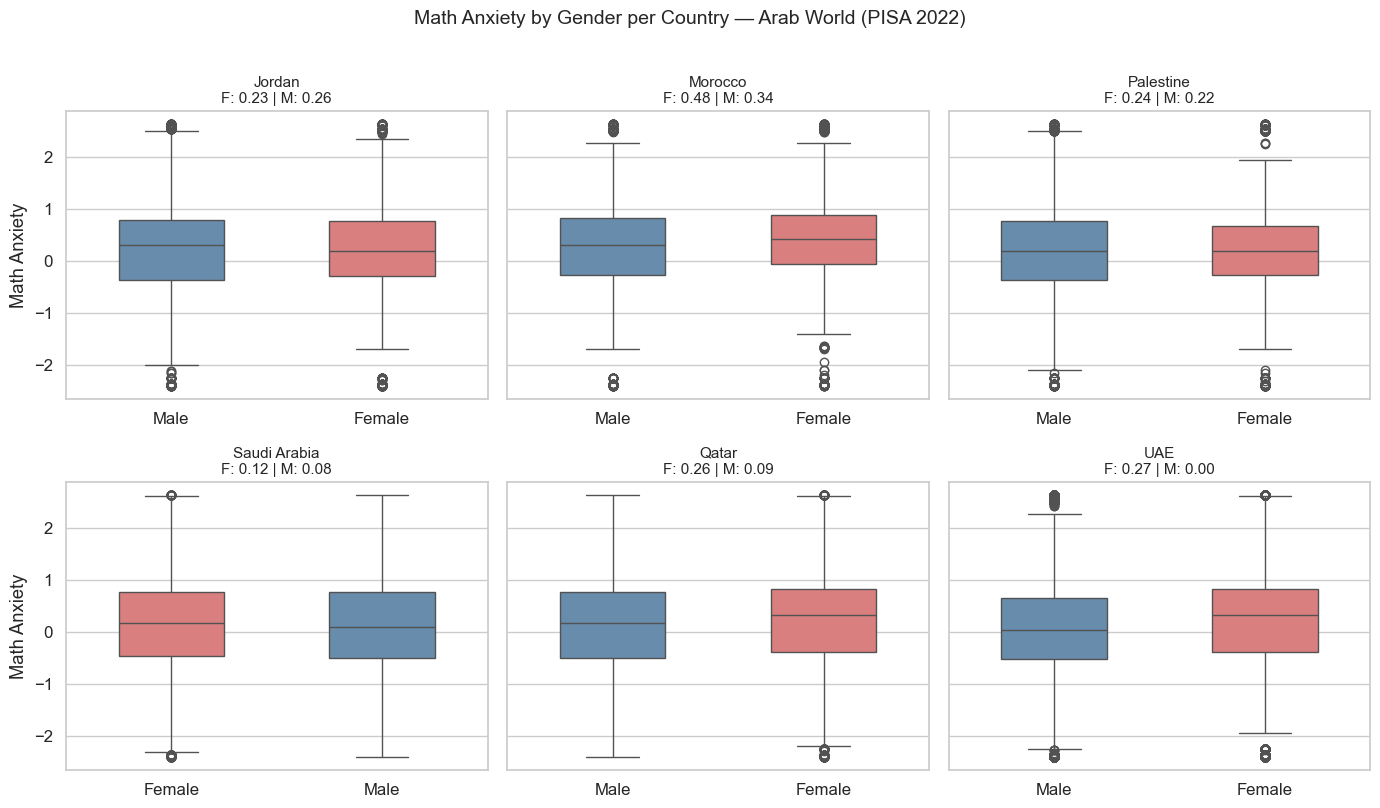

In [15]:
# Plot 11a: Box plots of math anxiety by gender, per country
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, country in enumerate(country_order):
    subset = df[df['country'] == country].dropna(subset=['math_anxiety'])
    sb.boxplot(
        data=subset, x='gender', y='math_anxiety',
        palette={'Female': '#E87070', 'Male': '#5B8DB8'},
        ax=axes[i], width=0.5
    )
    mean_f = subset[subset['gender'] == 'Female']['math_anxiety'].mean()
    mean_m = subset[subset['gender'] == 'Male']['math_anxiety'].mean()
    axes[i].set_title(f'{country}\nF: {mean_f:.2f} | M: {mean_m:.2f}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Math Anxiety' if i % 3 == 0 else '')

fig.suptitle('Math Anxiety by Gender per Country — Arab World (PISA 2022)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

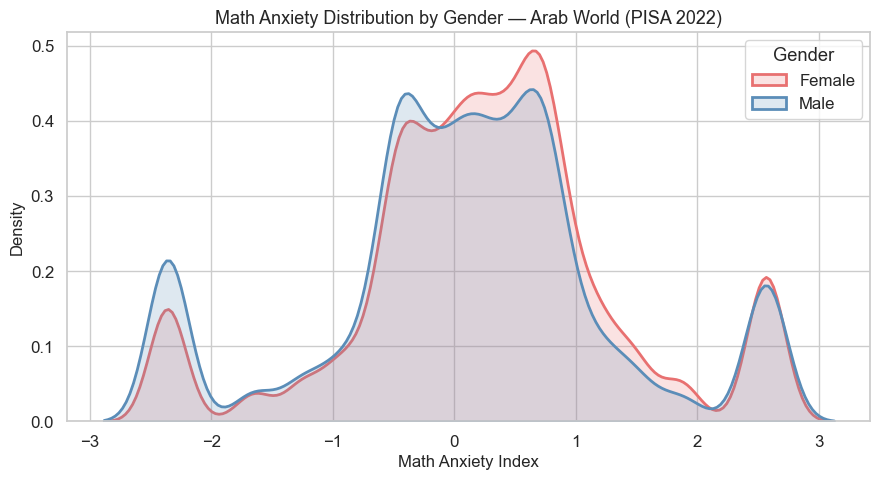

In [16]:
# Plot 11b: KDE plot of math anxiety distribution by gender
fig, ax = plt.subplots(figsize=(9, 5))

for gender, color in [('Female', '#E87070'), ('Male', '#5B8DB8')]:
    subset = df[df['gender'] == gender]['math_anxiety'].dropna()
    sb.kdeplot(subset, ax=ax, label=gender, color=color, linewidth=2, fill=True, alpha=0.2)

ax.set_xlabel('Math Anxiety Index', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Math Anxiety Distribution by Gender — Arab World (PISA 2022)', fontsize=13)
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

**Observation:** The KDE plot shows that the math anxiety distributions for boys and girls follow a very similar shape, with three visible peaks around -2.5, 0.6, and 2.7 for both genders. The female distribution is shifted slightly to the right, indicating marginally higher anxiety on average. The box plots break this down by country — girls report higher mean anxiety than boys in 5 out of 6 countries, with the largest gaps in Morocco (F: 0.48 vs M: 0.34), Qatar (F: 0.26 vs M: 0.09), and UAE (F: 0.27 vs M: 0.00). Jordan is the only country where boys report slightly higher anxiety than girls. Overall though, the differences are relatively small and the spreads overlap heavily in all countries.

### Talk about some of the relationships you observed in the multivariate exploration.

A few things stood out. The SES–math relationship is positive for both genders across all 6 countries, but the slopes aren't the same everywhere — in Jordan, Qatar, and Palestine, girls gain more from higher SES than boys do, while in Saudi Arabia it's the opposite. Qatar and UAE show the largest gaps between their lowest and highest SES quartiles, while Jordan and Palestine have the smallest gaps, though even their top quartile students barely reach the regional mean of 400.

### Were there any interesting or surprising interactions?

One pattern worth noting is that girls report higher math anxiety than boys in 5 out of 6 countries — most noticeably in Morocco, Qatar, and UAE — yet they still score higher in math in those same countries. The anxiety distributions for both genders follow a similar multimodal shape, so the difference isn't dramatic, but the direction is consistent. Jordan is the only exception where boys report slightly higher anxiety than girls.

## Conclusions

Here's a summary of what I found from exploring this dataset:

1. **Math scores differ by country**: UAE (434) and Qatar (412) have the highest averages, while Jordan (360), Morocco (363), and Palestine (365) score the lowest. Saudi Arabia sits in between at 389.

2. **Girls outperform boys in most countries**: In 5 out of 6 countries girls score higher in math, with the largest gaps in Palestine (17 points) and Jordan (16 points). Saudi Arabia is the only exception where boys score slightly higher.

3. **SES is strongly associated with math performance**: Scores go up consistently from Q1 (355) to Q4 (450), a gap of about 95 points. The biggest jump happens between Q2 and Q3.

4. **Qatar and UAE show the largest within-country inequality**: The gap between their lowest and highest SES quartiles is around 95–100 points, compared to 43–50 points in Jordan and Palestine.

5. **Girls report higher math anxiety than boys in most countries, yet score higher**: The difference is most visible in Morocco, Qatar, and UAE. Jordan is the only country where boys report slightly higher anxiety.